# Three-Way RAG Benchmark

This notebook benchmarks Vector RAG, Vectorless RAG, and Hybrid RAG on the 20-question test set in `evaluation/test_questions.json`.

It reuses the existing persisted indexes, runs the shared evaluator, saves an enriched question-level CSV plus a summary CSV, and renders a pandas/matplotlib dashboard under `evaluation/results/`.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'config.py').exists() and (candidate / 'evaluation' / 'test_questions.json').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the notebook working directory.')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vector_rag.pipeline import VectorRAGPipeline
from vectorless_rag.pipeline import VectorlessRAGPipeline
from hybrid_rag.pipeline import HybridRAGPipeline
from evaluation.evaluator import run_evaluation

RESULTS_DIR = REPO_ROOT / 'evaluation' / 'results'
QUESTIONS_PATH = REPO_ROOT / 'evaluation' / 'test_questions.json'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ['vector', 'vectorless', 'hybrid']
METHOD_LABELS = {
    'vector': 'Vector RAG',
    'vectorless': 'Vectorless RAG',
    'hybrid': 'Hybrid RAG',
}
METHOD_COLORS = {
    'vector': '#1f77b4',
    'vectorless': '#ff7f0e',
    'hybrid': '#2ca02c',
}
CATEGORY_ORDER = None
DIFFICULTY_ORDER = ['easy', 'medium', 'hard']
COMPANY_ORDER = ['NVIDIA', 'MICROSOFT', 'NETFLIX', 'AMAZON']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

def method_label(method: str) -> str:
    return METHOD_LABELS.get(method, method.title())

def save_figure(fig, filename: str) -> Path:
    output_path = RESULTS_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    return output_path

def ordered_pivot(df: pd.DataFrame, index_col: str, order: list[str]) -> pd.DataFrame:
    table = (
        df.pivot_table(index=index_col, columns='method', values='judge_score', aggfunc='mean')
          .reindex(order)
          .reindex(columns=METHOD_ORDER)
    )
    return table

def annotate_bars(ax, bars, offset: float, fmt: str, fontsize: int = 9):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha='center',
            va='bottom',
            fontsize=fontsize,
            fontweight='bold',
        )

def draw_heatmap(table: pd.DataFrame, title: str, filename: str, value_fmt: str = '{:.2f}', cmap: str = 'YlGnBu'):
    values = table.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(1.2 + 1.6 * table.shape[1], 1.4 + 0.85 * table.shape[0]))
    im = ax.imshow(values, aspect='auto', cmap=cmap, vmin=1, vmax=5)
    ax.set_title(title, fontweight='bold', pad=12)
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels([method_label(col) for col in table.columns], rotation=0)
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels([str(idx).replace('_', ' ').title() for idx in table.index])
    ax.set_xlabel('Model')
    ax.set_ylabel('Group')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Avg judge score')
    threshold = 3.0
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = values[i, j]
            if np.isnan(value):
                label = 'NA'
                color = 'black'
            else:
                label = value_fmt.format(value)
                color = 'white' if value >= threshold else 'black'
            ax.text(j, i, label, ha='center', va='center', color=color, fontsize=10, fontweight='bold')
    plt.tight_layout()
    output_path = save_figure(fig, filename)
    plt.show()
    plt.close(fig)
    print(f'Saved {output_path}')


In [2]:
with QUESTIONS_PATH.open(encoding='utf-8') as f:
    question_payload = json.load(f)

questions = question_payload['questions']
total_questions = question_payload.get('metadata', {}).get('total_questions', len(questions))
difficulty_lookup = pd.DataFrame(questions)[['id', 'difficulty']].copy()

print(f'Loaded {total_questions} questions for the benchmark.')
print('Initialising pipelines...')
vector_rag = VectorRAGPipeline()
vectorless_rag = VectorlessRAGPipeline()
hybrid_rag = HybridRAGPipeline()
print('All three pipelines are ready.')

results_df = run_evaluation(
    vector_rag,
    vectorless_rag,
    hybrid_pipeline=hybrid_rag,
    results_filename='three_way_results.csv',
)

results_df = results_df.merge(difficulty_lookup, on='id', how='left')
assert results_df['difficulty'].notna().all(), 'Difficulty merge failed for one or more rows.'

results_path = RESULTS_DIR / 'three_way_results.csv'
results_df.to_csv(results_path, index=False, encoding='utf-8')

expected_rows = total_questions * len(METHOD_ORDER)
assert len(results_df) == expected_rows, f'Expected {expected_rows} rows, got {len(results_df)}.'
assert results_df.groupby('method').size().reindex(METHOD_ORDER).eq(total_questions).all(), 'Each method should answer every question exactly once.'
assert results_df['judge_score'].notna().all(), 'Missing judge_score values.'
assert (results_df['pass'] == (results_df['judge_score'] >= 3)).all(), 'Pass flag mismatch.'
assert set(results_df['method']) == set(METHOD_ORDER), f'Unexpected methods found: {sorted(results_df["method"].unique().tolist())}.'

summary_df = (
    results_df.groupby('method', as_index=False)
    .agg(
        questions=('id', 'count'),
        avg_judge_score=('judge_score', 'mean'),
        pass_rate_pct=('pass', lambda s: s.mean() * 100),
        company_accuracy_pct=('company_accuracy', lambda s: s.mean() * 100),
        avg_retrieval_time_s=('retrieval_time', 'mean'),
        avg_generation_time_s=('generation_time', 'mean'),
        avg_total_time_s=('total_time', 'mean'),
    )
)
summary_df['method_label'] = summary_df['method'].map(METHOD_LABELS)
summary_df = summary_df.set_index('method').reindex(METHOD_ORDER).reset_index()
summary_df = summary_df[[
    'method',
    'method_label',
    'questions',
    'avg_judge_score',
    'pass_rate_pct',
    'company_accuracy_pct',
    'avg_retrieval_time_s',
    'avg_generation_time_s',
    'avg_total_time_s',
]]

summary_path = RESULTS_DIR / 'three_way_summary.csv'
summary_df.to_csv(summary_path, index=False, encoding='utf-8')

question_counts = results_df.groupby('method').size().reindex(METHOD_ORDER).to_frame('questions')

CATEGORY_ORDER = sorted(results_df['category'].dropna().unique())

# Normalize company names to match COMPANY_ORDER
results_df['company'] = results_df['company'].str.upper()

category_table = ordered_pivot(results_df, 'category', CATEGORY_ORDER)
difficulty_table = ordered_pivot(results_df, 'difficulty', DIFFICULTY_ORDER)
company_table = ordered_pivot(results_df, 'company', COMPANY_ORDER)

assert category_table.notna().all().all(), 'Missing category cells in the pivot table.'
assert difficulty_table.notna().all().all(), 'Missing difficulty cells in the pivot table.'
assert company_table.notna().all().all(), 'Missing company cells in the pivot table.'

display(question_counts)
display(summary_df.style.format({
    'avg_judge_score': '{:.2f}',
    'pass_rate_pct': '{:.1f}%',
    'company_accuracy_pct': '{:.1f}%',
    'avg_retrieval_time_s': '{:.4f}',
    'avg_generation_time_s': '{:.2f}',
    'avg_total_time_s': '{:.2f}',
}))
display(category_table.round(2))
display(difficulty_table.round(2))
display(company_table.round(2))

print(f'Saved enriched results to {results_path}')
print(f'Saved summary to {summary_path}')

Loaded 20 questions for the benchmark.
Initialising pipelines...
🔧 Initialising Vector RAG Pipeline...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ ChromaDB loaded — 7913 child vectors
Mistral client ready - model: mistral-medium-latest
✅ Vector RAG ready — 2010 parents in lookup

🔧 Initialising Vectorless RAG Pipeline...
✅ BM25 loaded — 7913 children
Mistral client already initialised - reusing
✅ Vectorless RAG ready — 7913 children, 2010 parents

🔧 Initialising Hybrid RAG Pipeline...
✅ ChromaDB loaded — 7913 child vectors
✅ BM25 loaded — 7913 children
Mistral client already initialised - reusing
✅ Hybrid RAG ready — 7913 vectors | 7913 BM25 children | 2010 parents

All three pipelines are ready.
Mistral judge ready - model: mistral-medium-latest

   PHASE 5 - EVALUATION (20 questions × 3 methods)
   Methods         : vector, vectorless, hybrid
   Generation limit: 18 RPM
   Judge limit     : 12 RPM



Questions:   0%|          | 0/20 [00:00<?, ?it/s]


[1/20] Q001 - NVIDIA
🔁 Loading reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


...

,method,method_label,questions,avg_judge_score,pass_rate_pct,company_accuracy_pct,avg_retrieval_time_s,avg_generation_time_s,avg_total_time_s
0,vector,Vector RAG,20,4.50,95.0%,100.0%,0.6679,1.34,2.88
1,vectorless,Vectorless RAG,20,4.70,100.0%,100.0%,0.0528,1.35,1.66
2,hybrid,Hybrid RAG,20,4.60,100.0%,100.0%,0.6346,1.41,2.34


method,vector,vectorless,hybrid
category,,,
accounting_and_tax,5.00,5.00,5.00
business_drivers,4.00,5.00,5.00
business_model,3.00,5.00,5.00
capital_expenditure,5.00,5.00,5.00
cloud_metrics,5.00,3.00,3.00
commitments_and_contingencies,5.00,5.00,5.00
commitments_and_leases,5.00,5.00,5.00
debt_and_liquidity,5.00,5.00,5.00
financial_metrics,3.75,4.50,4.50


method,vector,vectorless,hybrid
difficulty,,,
easy,4.17,4.67,4.67
medium,4.43,4.71,4.71
hard,4.86,4.71,4.43


method,vector,vectorless,hybrid
company,,,
NVIDIA,4.8,5.0,5.0
MICROSOFT,4.6,4.2,4.2
NETFLIX,4.2,4.6,4.2
AMAZON,4.4,5.0,5.0


Saved enriched results to C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_results.csv
Saved summary to C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_summary.csv


In [3]:
results_df['company'] = results_df['company'].str.upper()

company_table = ordered_pivot(results_df, 'company', COMPANY_ORDER)

print(company_table)

method     vector  vectorless  hybrid
company                              
NVIDIA        4.8         5.0     5.0
MICROSOFT     4.6         4.2     4.2
NETFLIX       4.2         4.6     4.2
AMAZON        4.4         5.0     5.0


In [4]:
print(COMPANY_ORDER)

['NVIDIA', 'MICROSOFT', 'NETFLIX', 'AMAZON']


In [5]:
print(category_table)
print(sorted(results_df["category"].unique()))
print(CATEGORY_ORDER)

method                           vector  vectorless    hybrid
category                                                     
accounting_and_tax             5.000000    5.000000  5.000000
business_drivers               4.000000    5.000000  5.000000
business_model                 3.000000    5.000000  5.000000
capital_expenditure            5.000000    5.000000  5.000000
cloud_metrics                  5.000000    3.000000  3.000000
commitments_and_contingencies  5.000000    5.000000  5.000000
commitments_and_leases         5.000000    5.000000  5.000000
debt_and_liquidity             5.000000    5.000000  5.000000
financial_metrics              3.750000    4.500000  4.500000
foreign_exchange_risk          5.000000    5.000000  3.000000
guidance                       5.000000    5.000000  5.000000
revenue_recognition            5.000000    5.000000  5.000000
revenue_sources                5.000000    5.000000  5.000000
risk_factors                   5.000000    5.000000  5.000000
segment_

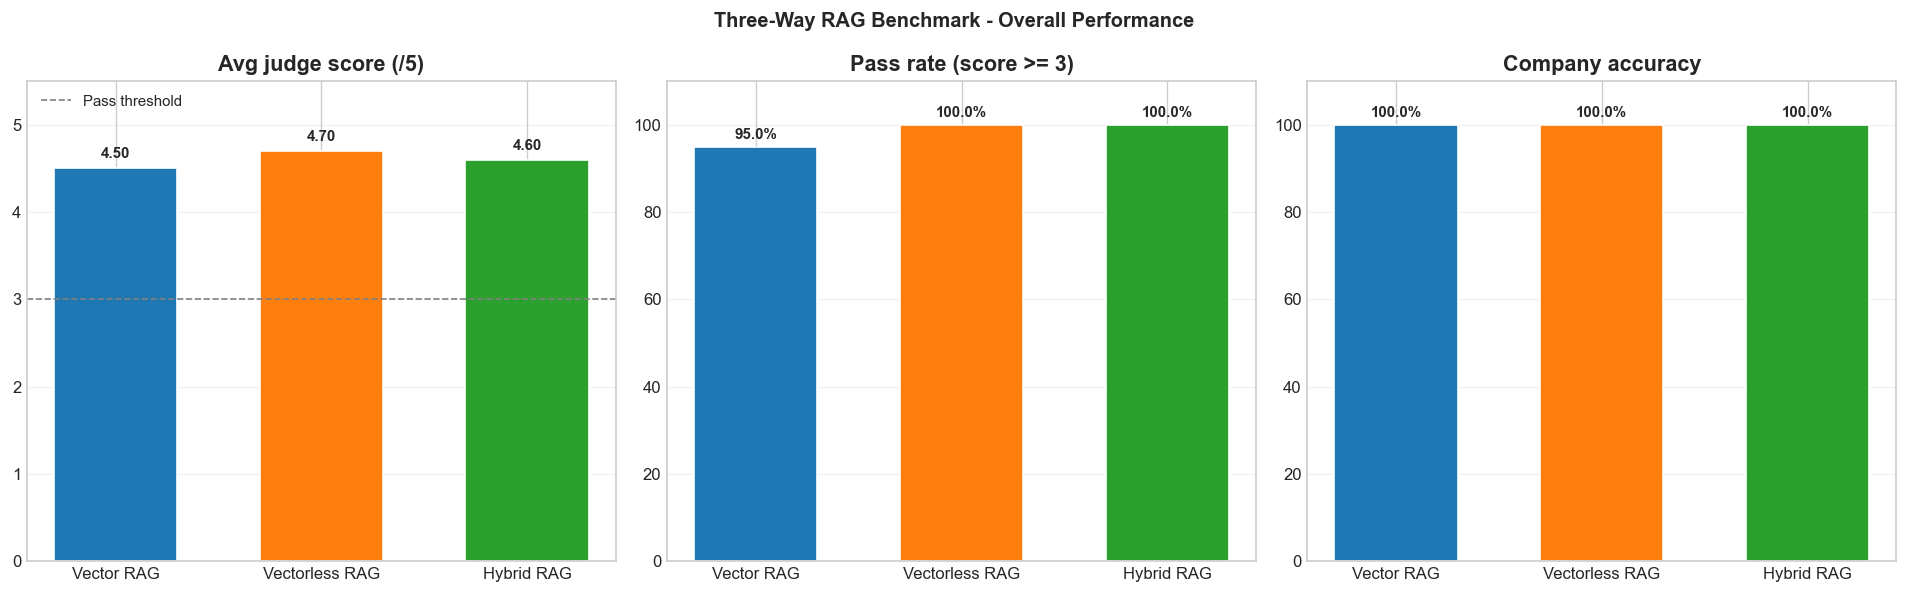

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_overall.png


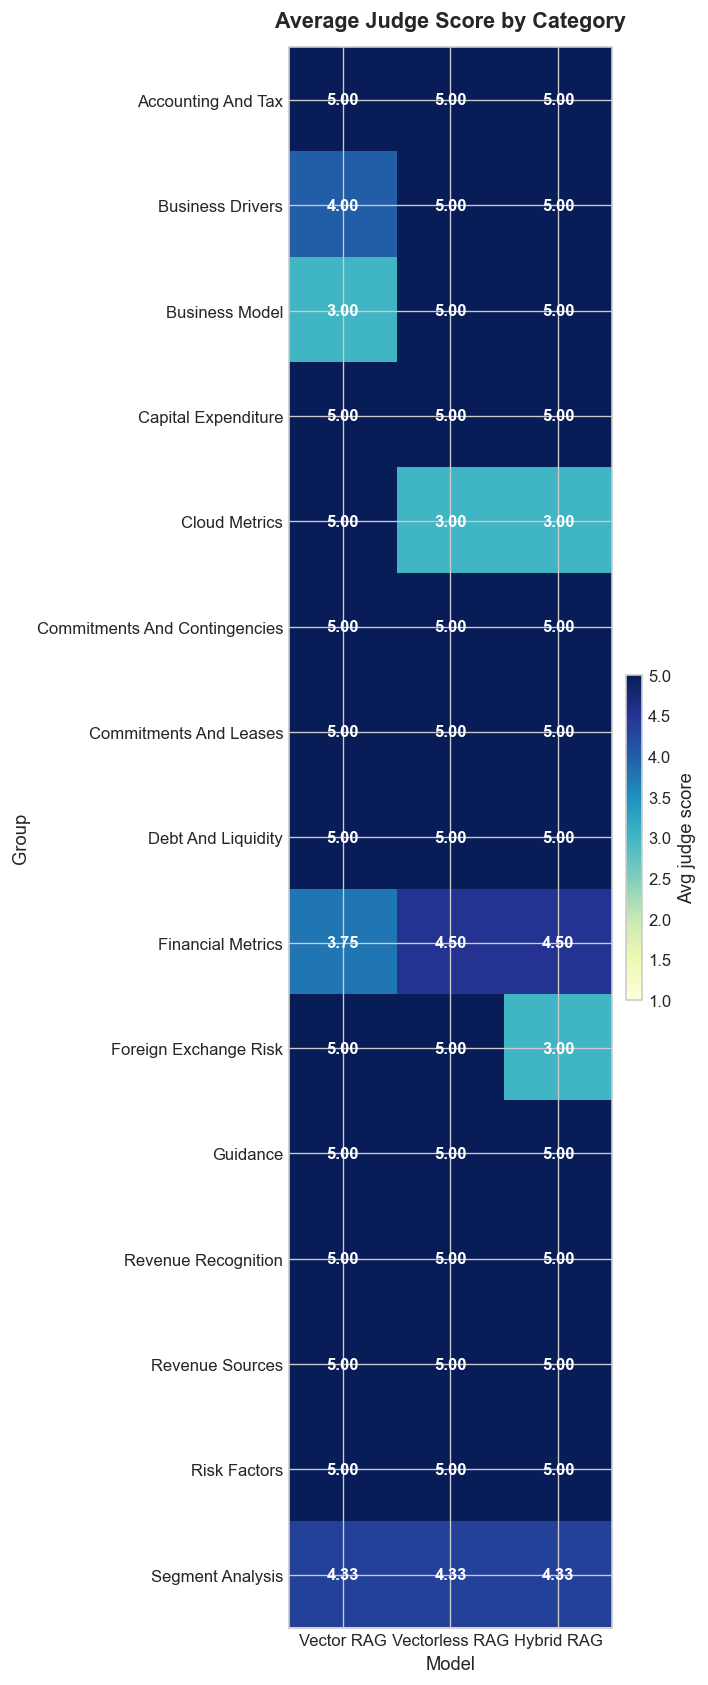

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_category_heatmap.png


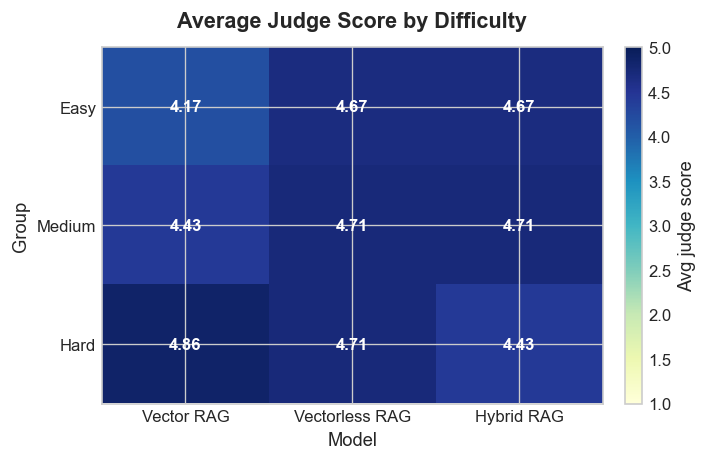

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_difficulty_heatmap.png


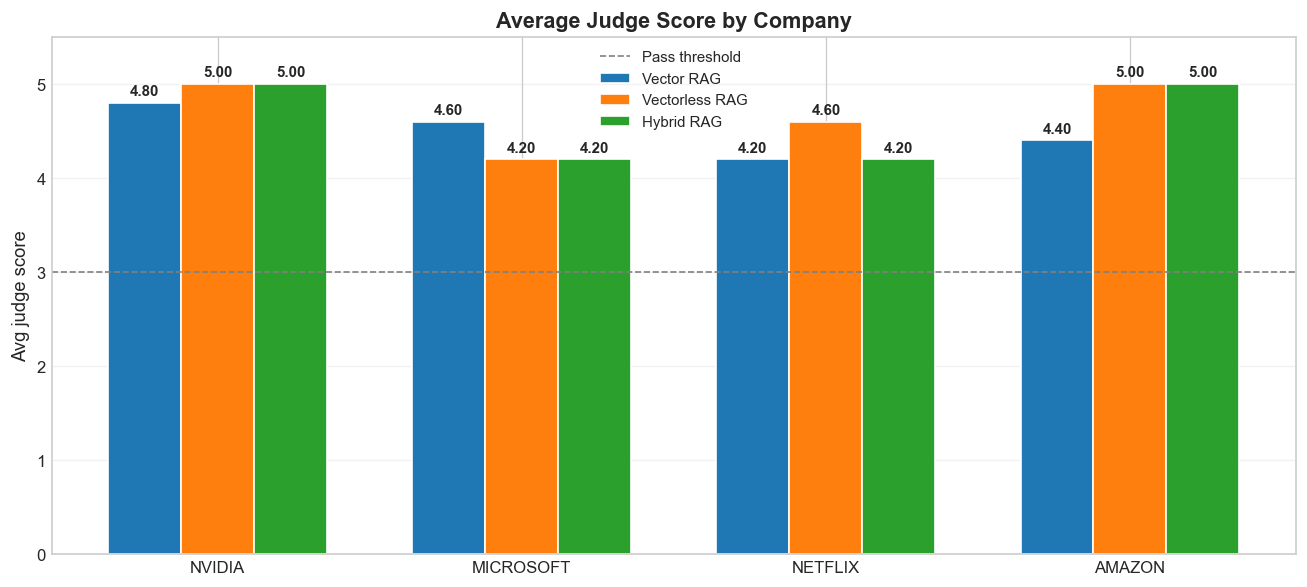

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_company.png


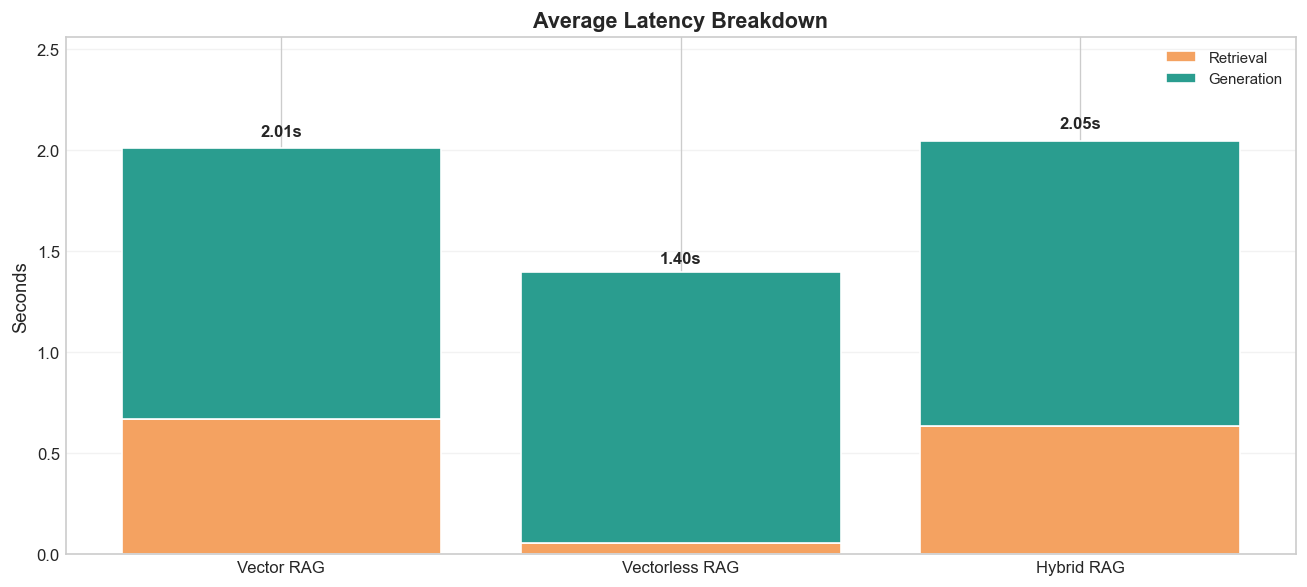

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_latency.png


C:\Users\nagal\AppData\Local\Temp\ipykernel_12208\957529246.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


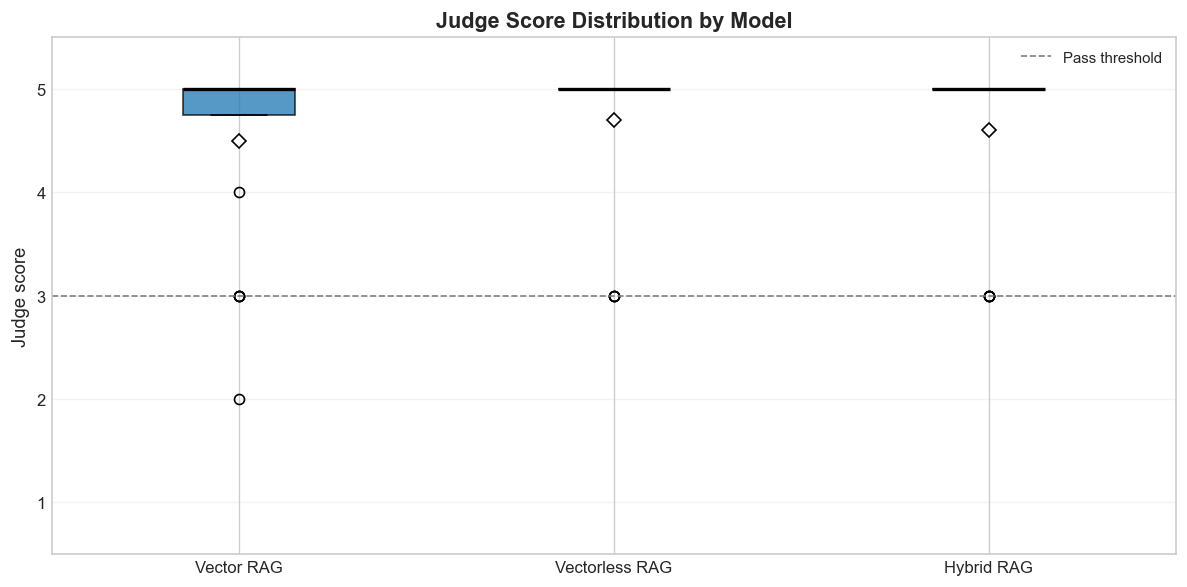

Saved C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_chart_distribution.png
Three-way benchmark takeaways
Best answer quality: Vectorless RAG (4.70/5)
Fastest end-to-end latency: Vectorless RAG (1.66s)
Results CSV: C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_results.csv
Summary CSV: C:\Users\nagal\Documents\AI\rag-benchmark\evaluation\results\three_way_summary.csv


In [6]:
summary_ordered = summary_df.set_index('method').loc[METHOD_ORDER].reset_index()
summary_colors = [METHOD_COLORS[method] for method in summary_ordered['method']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Three-Way RAG Benchmark - Overall Performance', fontweight='bold')

overall_metrics = [
    ('avg_judge_score', 'Avg judge score (/5)', 0, 5.5, '{:.2f}', 0.08),
    ('pass_rate_pct', 'Pass rate (score >= 3)', 0, 110, '{:.1f}%', 1.0),
    ('company_accuracy_pct', 'Company accuracy', 0, 110, '{:.1f}%', 1.0),
]

for ax, (column, title, ymin, ymax, fmt, offset) in zip(axes, overall_metrics):
    bars = ax.bar(
        summary_ordered['method_label'],
        summary_ordered[column],
        color=summary_colors,
        edgecolor='white',
        width=0.6,
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', alpha=0.25)
    if column == 'avg_judge_score':
        ax.axhline(3, color='gray', linestyle='--', linewidth=1, label='Pass threshold')
        ax.legend(loc='upper left')
    annotate_bars(ax, bars, offset=offset, fmt=fmt)

plt.tight_layout()
overall_path = save_figure(fig, 'three_way_chart_overall.png')
plt.show()
plt.close(fig)
print(f'Saved {overall_path}')

draw_heatmap(category_table, 'Average Judge Score by Category', 'three_way_chart_category_heatmap.png')
draw_heatmap(difficulty_table, 'Average Judge Score by Difficulty', 'three_way_chart_difficulty_heatmap.png')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(company_table.index))
width = 0.24
for offset, method in enumerate(METHOD_ORDER):
    values = company_table[method].to_numpy()
    bars = ax.bar(
        x + (offset - 1) * width,
        values,
        width,
        label=METHOD_LABELS[method],
        color=METHOD_COLORS[method],
        edgecolor='white',
    )
    annotate_bars(ax, bars, offset=0.05, fmt='{:.2f}')

ax.set_title('Average Judge Score by Company', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(company_table.index)
ax.set_ylabel('Avg judge score')
ax.set_ylim(0, 5.5)
ax.axhline(3, color='gray', linestyle='--', linewidth=1, label='Pass threshold')
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.tight_layout()
company_path = save_figure(fig, 'three_way_chart_company.png')
plt.show()
plt.close(fig)
print(f'Saved {company_path}')

fig, ax = plt.subplots(figsize=(11, 5))
retrieval = summary_ordered['avg_retrieval_time_s'].to_numpy()
generation = summary_ordered['avg_generation_time_s'].to_numpy()
x = np.arange(len(summary_ordered))
ax.bar(x, retrieval, color='#F4A261', edgecolor='white', label='Retrieval')
ax.bar(x, generation, bottom=retrieval, color='#2A9D8F', edgecolor='white', label='Generation')
for idx, total in enumerate(retrieval + generation):
    ax.text(idx, total + max(total * 0.03, 0.03), f'{total:.2f}s', ha='center', fontweight='bold')
ax.set_title('Average Latency Breakdown', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary_ordered['method_label'])
ax.set_ylabel('Seconds')
ax.set_ylim(0, (retrieval + generation).max() * 1.25)
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.tight_layout()
latency_path = save_figure(fig, 'three_way_chart_latency.png')
plt.show()
plt.close(fig)
print(f'Saved {latency_path}')

fig, ax = plt.subplots(figsize=(10, 5))
score_data = [results_df.loc[results_df['method'] == method, 'judge_score'].astype(float).to_numpy() for method in METHOD_ORDER]
box = ax.boxplot(
    score_data,
    labels=[METHOD_LABELS[method] for method in METHOD_ORDER],
    patch_artist=True,
    showmeans=True,
    meanprops={
        'marker': 'D',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 6,
    },
    medianprops={'color': 'black', 'linewidth': 2},
)
for patch, method in zip(box['boxes'], METHOD_ORDER):
    patch.set_facecolor(METHOD_COLORS[method])
    patch.set_alpha(0.75)
ax.axhline(3, color='gray', linestyle='--', linewidth=1, label='Pass threshold')
ax.set_title('Judge Score Distribution by Model', fontweight='bold')
ax.set_ylabel('Judge score')
ax.set_ylim(0.5, 5.5)
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.tight_layout()
distribution_path = save_figure(fig, 'three_way_chart_distribution.png')
plt.show()
plt.close(fig)
print(f'Saved {distribution_path}')

best_quality = summary_ordered.loc[summary_ordered['avg_judge_score'].idxmax()]
fastest_total = summary_ordered.loc[summary_ordered['avg_total_time_s'].idxmin()]

print('=' * 72)
print('Three-way benchmark takeaways')
print(f"Best answer quality: {best_quality['method_label']} ({best_quality['avg_judge_score']:.2f}/5)")
print(f"Fastest end-to-end latency: {fastest_total['method_label']} ({fastest_total['avg_total_time_s']:.2f}s)")
print(f'Results CSV: {results_path}')
print(f'Summary CSV: {summary_path}')
print('=' * 72)
